In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold

In [2]:
project_root = Path.cwd().parent

train_path = (
    project_root
    / "data"
    / "raw"
    / "UNSW_NB15_training-set.csv"
)

test_path = (
    project_root
    / "data"
    / "raw"
    / "UNSW_NB15_testing-set.csv"
)

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(train_df.shape)
print(test_df.shape)

(175341, 45)
(82332, 45)


In [3]:
excluded_columns = ["id","label","attack_cat","is_ftp_login"]
binary_feature_columns = [
    column
    for column in train_df.columns
    if column not in excluded_columns
]

print("Binary input feature count:", len(binary_feature_columns))

Binary input feature count: 41


In [4]:
binary_data = (
    train_df[binary_feature_columns + ["label"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Before binary deduplication:", len(train_df))
print("After binary deduplication:", len(binary_data))
print("Removed records:", len(train_df) - len(binary_data))

Before binary deduplication: 175341
After binary deduplication: 101269
Removed records: 74072


In [5]:
X = binary_data[binary_feature_columns]
y = binary_data["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (101269, 41)
y shape: (101269,)


In [6]:
groups = pd.util.hash_pandas_object(
    X,
    index=False
)

print("Unique feature patterns:", groups.nunique())

Unique feature patterns: 101040


In [7]:
splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_indices, validation_indices = next(
    splitter.split(X, y, groups)
)

X_train = X.iloc[train_indices].copy()
X_validation = X.iloc[validation_indices].copy()

y_train = y.iloc[train_indices].copy()
y_validation = y.iloc[validation_indices].copy()

print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)

Training shape: (81016, 41)
Validation shape: (20253, 41)


In [8]:
training_groups = set(groups.iloc[train_indices])
validation_groups = set(groups.iloc[validation_indices])

group_overlap = training_groups.intersection(
    validation_groups
)

print("Train-validation feature overlap:", len(group_overlap))

Train-validation feature overlap: 0


In [9]:
def show_class_distribution(name, target):
    percentages = (
        target.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

    print(f"\n{name}:")
    print(percentages)


show_class_distribution("Full binary dataset", y)
show_class_distribution("Training subset", y_train)
show_class_distribution("Validation subset", y_validation)


Full binary dataset:
label
0    51.24
1    48.76
Name: proportion, dtype: float64

Training subset:
label
0    51.24
1    48.76
Name: proportion, dtype: float64

Validation subset:
label
0    51.24
1    48.76
Name: proportion, dtype: float64


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [11]:
numerical_features = (
    X_train
    .select_dtypes(include="number")
    .columns
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(exclude="number")
    .columns
    .tolist()
)

print("Numerical features:", len(numerical_features))
print("Categorical features:", categorical_features)

Numerical features: 38
Categorical features: ['proto', 'service', 'state']


In [12]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [13]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [15]:
X_train_processed = preprocessor.fit_transform(X_train)
X_validation_processed = preprocessor.transform(X_validation)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_validation_processed.shape)
print("Output type:", type(X_train_processed))

Processed training shape: (81016, 193)
Processed validation shape: (20253, 193)
Output type: <class 'scipy.sparse._csr.csr_matrix'>


In [16]:
processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print("Processed feature count:", len(processed_feature_names))
print(processed_feature_names[:20])
print(processed_feature_names[-20:])

Processed feature count: 193
['numerical__dur' 'numerical__spkts' 'numerical__dpkts'
 'numerical__sbytes' 'numerical__dbytes' 'numerical__rate'
 'numerical__sttl' 'numerical__dttl' 'numerical__sload' 'numerical__dload'
 'numerical__sloss' 'numerical__dloss' 'numerical__sinpkt'
 'numerical__dinpkt' 'numerical__sjit' 'numerical__djit' 'numerical__swin'
 'numerical__stcpb' 'numerical__dtcpb' 'numerical__dwin']
['categorical__service_dns' 'categorical__service_ftp'
 'categorical__service_ftp-data' 'categorical__service_http'
 'categorical__service_irc' 'categorical__service_pop3'
 'categorical__service_radius' 'categorical__service_smtp'
 'categorical__service_snmp' 'categorical__service_ssh'
 'categorical__service_ssl' 'categorical__state_CON'
 'categorical__state_ECO' 'categorical__state_FIN'
 'categorical__state_INT' 'categorical__state_PAR'
 'categorical__state_REQ' 'categorical__state_RST'
 'categorical__state_URN' 'categorical__state_no']


In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

import matplotlib.pyplot as plt

In [28]:
def evaluate_binary_model(
    model_name,
    y_true,
    y_pred,
    y_probability=None
):
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }

    if y_probability is not None:
        results["roc_auc"] = roc_auc_score(
            y_true,
            y_probability
        )
        results["average_precision"] = average_precision_score(
        y_true,
        y_probability
        )

    return results

In [29]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(
    X_train_processed,
    y_train
)

dummy_predictions = dummy_model.predict(
    X_validation_processed
)

dummy_results = evaluate_binary_model(
    "Dummy Classifier",
    y_validation,
    dummy_predictions
)

print(dummy_results)

{'model': 'Dummy Classifier', 'accuracy': 0.5124179133955463, 'precision': 0.0, 'recall': 0.0, 'f1_score': 0.0}


In [30]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [31]:
logistic_predictions = logistic_model.predict(
    X_validation_processed
)

logistic_probabilities = (
    logistic_model.predict_proba(
        X_validation_processed
    )[:, 1]
)

In [32]:
logistic_results = evaluate_binary_model(
    "Logistic Regression",
    y_validation,
    logistic_predictions,
    logistic_probabilities
)

print(logistic_results)

{'model': 'Logistic Regression', 'accuracy': 0.8974472917592455, 'precision': 0.8392204628501827, 'recall': 0.9768101265822785, 'f1_score': 0.9028031260236792, 'roc_auc': 0.9656337627551954, 'average_precision': 0.9577867652088772}


In [33]:
print(
    classification_report(
        y_validation,
        logistic_predictions,
        target_names=["Normal", "Attack"],
        digits=4
    )
)

              precision    recall  f1-score   support

      Normal     0.9739    0.8219    0.8915     10378
      Attack     0.8392    0.9768    0.9028      9875

    accuracy                         0.8974     20253
   macro avg     0.9065    0.8994    0.8971     20253
weighted avg     0.9082    0.8974    0.8970     20253



In [34]:
confusion = confusion_matrix(
    y_validation,
    logistic_predictions
)

print(confusion)

[[8530 1848]
 [ 229 9646]]


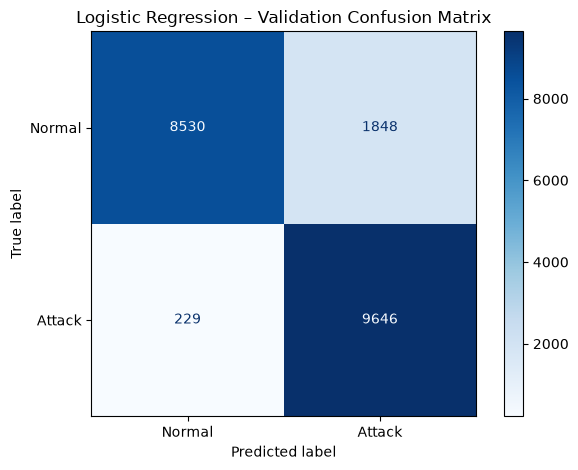

In [35]:
display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Normal", "Attack"]
)

display.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Logistic Regression – Validation Confusion Matrix"
)
plt.tight_layout()
plt.show()

In [36]:
comparison = pd.DataFrame([
    dummy_results,
    logistic_results
])

comparison

,model,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,Dummy Classifier,0.512418,0.00000,0.00000,0.000000,NaN,NaN
1,Logistic Regression,0.897447,0.83922,0.97681,0.902803,0.965634,0.957787


In [37]:
threshold_results = []

for threshold in [0.30, 0.50, 0.70, 0.90]:
    predictions = (
        logistic_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        predictions,
        labels=[0, 1]
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_validation, predictions, zero_division=0
        ),
        "attack_recall": recall_score(
            y_validation, predictions, zero_division=0
        ),
        "false_positive_rate": fp / (fp + tn),
        "false_alarms": fp,
        "missed_attacks": fn
    })

threshold_comparison = pd.DataFrame(threshold_results)
threshold_comparison.round(4)

,threshold,precision,attack_recall,false_positive_rate,false_alarms,missed_attacks
0,0.3,0.8319,0.9929,0.1909,1981,70
1,0.5,0.8392,0.9768,0.1781,1848,229
2,0.7,0.8990,0.8722,0.0933,968,1262
3,0.9,0.9834,0.4557,0.0073,76,5375


In [39]:
from IPython.display import display as show_table

print("Lowest-FPR candidate with attack recall >= 95%:")
show_table(best_candidate.round(4))

Lowest-FPR candidate with attack recall >= 95%:


,threshold,precision,attack_recall,false_positive_rate,false_alarms,missed_attacks
59,0.59,0.8532,0.9532,0.156,1619,462


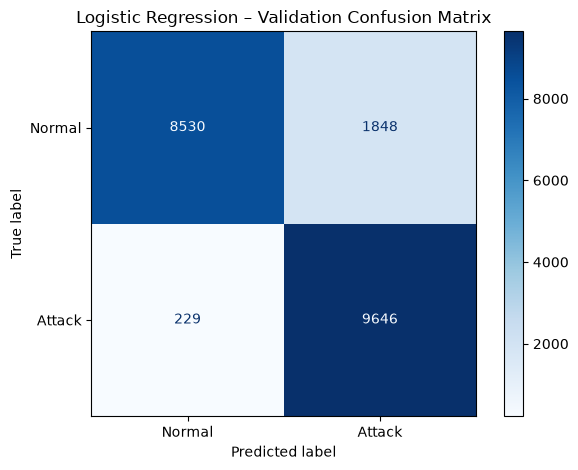

In [40]:
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Normal", "Attack"]
)

cm_display.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression – Validation Confusion Matrix")
plt.tight_layout()
plt.show()

Lowest-FPR candidate with attack recall >= 95%:
 threshold  precision  attack_recall  false_positive_rate  false_alarms  missed_attacks
      0.59     0.8532         0.9532                0.156          1619             462
Selected threshold: 0.59
[[8759 1619]
 [ 462 9413]]


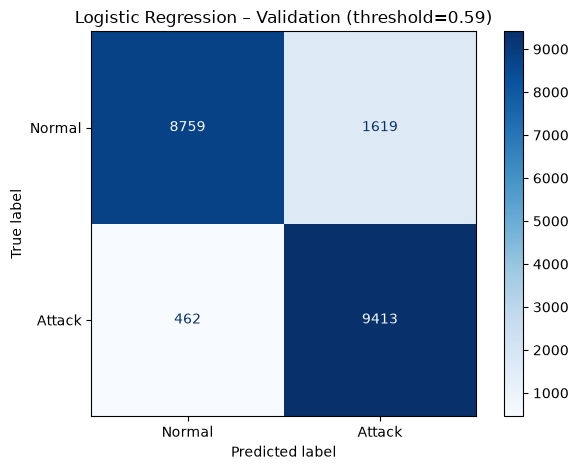

In [42]:
print("Lowest-FPR candidate with attack recall >= 95%:")
print(best_candidate.round(4).to_string(index=False))

selected_threshold = float(
    best_candidate["threshold"].iloc[0]
)

selected_predictions = (
    logistic_probabilities >= selected_threshold
).astype(int)

selected_confusion = confusion_matrix(
    y_validation,
    selected_predictions,
    labels=[0, 1]
)

print("Selected threshold:", selected_threshold)
print(selected_confusion)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=selected_confusion,
    display_labels=["Normal", "Attack"]
)

cm_display.plot(cmap="Blues", values_format="d")
plt.title(
    f"Logistic Regression – Validation (threshold={selected_threshold:.2f})"
)
plt.tight_layout()
plt.show()

Random Forest Model


In [43]:
from time import perf_counter

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=2
)

start_time = perf_counter()

random_forest_model.fit(
    X_train_processed,
    y_train
)

training_seconds = perf_counter() - start_time

print(f"Training time: {training_seconds:.2f} seconds")

Training time: 26.57 seconds


In [44]:
rf_predictions = random_forest_model.predict(
    X_validation_processed
)

attack_column = list(
    random_forest_model.classes_
).index(1)

rf_probabilities = random_forest_model.predict_proba(
    X_validation_processed
)[:, attack_column]

In [45]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(
    classification_report(
        y_validation,
        rf_predictions,
        labels=[0, 1],
        target_names=["Normal", "Attack"],
        digits=4,
        zero_division=0
    )
)

rf_confusion = confusion_matrix(
    y_validation,
    rf_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = rf_confusion.ravel()

print("Confusion matrix:")
print(rf_confusion)

print(f"\nFalse-positive rate: {fp / (fp + tn):.2%}")
print("False alarms:", fp)
print("Missed attacks:", fn)

              precision    recall  f1-score   support

      Normal     0.9568    0.8965    0.9257     10378
      Attack     0.8980    0.9575    0.9268      9875

    accuracy                         0.9262     20253
   macro avg     0.9274    0.9270    0.9262     20253
weighted avg     0.9281    0.9262    0.9262     20253

Confusion matrix:
[[9304 1074]
 [ 420 9455]]

False-positive rate: 10.35%
False alarms: 1074
Missed attacks: 420


In [46]:
from sklearn.metrics import f1_score

rf_training_predictions = random_forest_model.predict(
    X_train_processed
)

print(
    "Training Attack F1:",
    round(f1_score(y_train, rf_training_predictions), 4)
)

print(
    "Validation Attack F1:",
    round(f1_score(y_validation, rf_predictions), 4)
)

Training Attack F1: 0.9584
Validation Attack F1: 0.9268


In [47]:
rf_threshold_results = []

for threshold in np.linspace(0.0, 1.0, 101):
    predictions = (
        rf_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        predictions,
        labels=[0, 1]
    ).ravel()

    rf_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "attack_recall": tp / (tp + fn),
        "false_positive_rate": fp / (fp + tn),
        "false_alarms": fp,
        "missed_attacks": fn
    })

rf_threshold_table = pd.DataFrame(rf_threshold_results)

rf_best_candidate = (
    rf_threshold_table[
        rf_threshold_table["attack_recall"] >= 0.95
    ]
    .sort_values(
        ["false_positive_rate", "attack_recall", "threshold"],
        ascending=[True, False, True]
    )
    .head(1)
)

print("Random Forest candidate with recall >= 95%:")
print(rf_best_candidate.round(4).to_string(index=False))

Random Forest candidate with recall >= 95%:
 threshold  precision  attack_recall  false_positive_rate  false_alarms  missed_attacks
      0.51     0.9016         0.9529                0.099          1027             465


In [48]:
rf_selected_threshold = float(
    rf_best_candidate["threshold"].iloc[0]
)

rf_selected_predictions = (
    rf_probabilities >= rf_selected_threshold
).astype(int)

error_analysis = X_validation.copy()

# Match labels by row order
error_analysis["actual_label"] = y_validation.to_numpy()
error_analysis["predicted_label"] = rf_selected_predictions

error_analysis["false_alarm"] = (
    (error_analysis["actual_label"] == 0)
    & (error_analysis["predicted_label"] == 1)
)

error_analysis["missed_attack"] = (
    (error_analysis["actual_label"] == 1)
    & (error_analysis["predicted_label"] == 0)
)

error_analysis["is_normal"] = (
    error_analysis["actual_label"] == 0
)

error_analysis["is_attack"] = (
    error_analysis["actual_label"] == 1
)

service_errors = (
    error_analysis.groupby("service")
    .agg(
        normal_records=("is_normal", "sum"),
        attack_records=("is_attack", "sum"),
        false_alarms=("false_alarm", "sum"),
        missed_attacks=("missed_attack", "sum")
    )
)

service_errors["false_positive_rate"] = (
    service_errors["false_alarms"]
    / service_errors["normal_records"].replace(0, np.nan)
)

service_errors["attack_miss_rate"] = (
    service_errors["missed_attacks"]
    / service_errors["attack_records"].replace(0, np.nan)
)

print(
    service_errors
    .sort_values("false_alarms", ascending=False)
    .round(4)
    .to_string()
)

          normal_records  attack_records  false_alarms  missed_attacks  false_positive_rate  attack_miss_rate
service                                                                                                      
-                   6546            5157           851             384               0.1300            0.0745
http                1031            2584           117              62               0.1135            0.0240
ftp                  237             309            56              19               0.2363            0.0615
smtp                 282             659             2               0               0.0071            0.0000
ftp-data             486             148             1               0               0.0021            0.0000
dhcp                   0               9             0               0                  NaN            0.0000
dns                 1516             780             0               0               0.0000            0.0000
pop3      

In [49]:
unassigned_service = error_analysis[
    error_analysis["service"] == "-"
]

protocol_errors = (
    unassigned_service.groupby("proto")
    .agg(
        normal_records=("is_normal", "sum"),
        attack_records=("is_attack", "sum"),
        false_alarms=("false_alarm", "sum"),
        missed_attacks=("missed_attack", "sum")
    )
)

protocol_errors["false_positive_rate"] = (
    protocol_errors["false_alarms"]
    / protocol_errors["normal_records"].replace(0, np.nan)
)

protocol_errors["attack_miss_rate"] = (
    protocol_errors["missed_attacks"]
    / protocol_errors["attack_records"].replace(0, np.nan)
)

protocol_errors["total_errors"] = (
    protocol_errors["false_alarms"]
    + protocol_errors["missed_attacks"]
)

print(
    protocol_errors
    .sort_values("total_errors", ascending=False)
    .head(10)
    .round(4)
    .to_string()
)

            normal_records  attack_records  false_alarms  missed_attacks  false_positive_rate  attack_miss_rate  total_errors
proto                                                                                                                        
tcp                   5302            3620           604             335               0.1139            0.0925           939
udp                   1108            1242           244              49               0.2202            0.0395           293
igmp                     4               0             3               0               0.7500               NaN             3
3pc                      0               1             0               0                  NaN            0.0000             0
aris                     0               3             0               0                  NaN            0.0000             0
arp                    123               0             0               0               0.0000               NaN       

In [50]:
from sklearn.base import clone
from time import perf_counter

# Copy settings into a new, untrained model
rf_depth30 = clone(random_forest_model)
rf_depth30.set_params(max_depth=30)

start_time = perf_counter()

rf_depth30.fit(X_train_processed, y_train)

print(
    f"Training time: {perf_counter() - start_time:.2f} seconds"
)

depth30_train_predictions = rf_depth30.predict(
    X_train_processed
)

depth30_validation_predictions = rf_depth30.predict(
    X_validation_processed
)

tn, fp, fn, tp = confusion_matrix(
    y_validation,
    depth30_validation_predictions,
    labels=[0, 1]
).ravel()

print(
    "Training Attack F1:",
    round(f1_score(y_train, depth30_train_predictions), 4)
)

print(
    "Validation Attack F1:",
    round(
        f1_score(y_validation, depth30_validation_predictions),
        4
    )
)

print(f"Attack recall: {tp / (tp + fn):.4f}")
print(f"False-positive rate: {fp / (fp + tn):.4f}")
print("False alarms:", fp)
print("Missed attacks:", fn)

Training time: 56.77 seconds
Training Attack F1: 0.9787
Validation Attack F1: 0.9286
Attack recall: 0.9565
False-positive rate: 0.0986
False alarms: 1023
Missed attacks: 430


In [51]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Use exactly the same input columns and column order
X_test = test_df[X_train.columns].copy()
y_test = test_df["label"].copy()

# Transform only: do not fit on test data
X_test_processed = preprocessor.transform(X_test)

attack_column = list(
    random_forest_model.classes_
).index(1)

test_probabilities = random_forest_model.predict_proba(
    X_test_processed
)[:, attack_column]

frozen_threshold = 0.51

test_predictions = (
    test_probabilities >= frozen_threshold
).astype(int)


def print_test_results(name, actual, predictions, probabilities):
    print(f"\n{name}")

    print(
        classification_report(
            actual,
            predictions,
            labels=[0, 1],
            target_names=["Normal", "Attack"],
            digits=4,
            zero_division=0
        )
    )

    matrix = confusion_matrix(
        actual,
        predictions,
        labels=[0, 1]
    )

    tn, fp, fn, tp = matrix.ravel()

    print("Confusion matrix:")
    print(matrix)
    print(f"False-positive rate: {fp / (fp + tn):.4f}")
    print("False alarms:", fp)
    print("Missed attacks:", fn)

    if actual.nunique() == 2:
        print(
            f"ROC-AUC: {roc_auc_score(actual, probabilities):.4f}"
        )
        print(
            "Average precision:",
            round(average_precision_score(actual, probabilities), 4)
        )


print_test_results(
    "Official test set — RF depth 20, threshold 0.51",
    y_test,
    test_predictions,
    test_probabilities
)


Official test set — RF depth 20, threshold 0.51
              precision    recall  f1-score   support

      Normal     0.9799    0.7235    0.8324     37000
      Attack     0.8140    0.9879    0.8926     45332

    accuracy                         0.8691     82332
   macro avg     0.8970    0.8557    0.8625     82332
weighted avg     0.8886    0.8691    0.8656     82332

Confusion matrix:
[[26770 10230]
 [  548 44784]]
False-positive rate: 0.2765
False alarms: 10230
Missed attacks: 548
ROC-AUC: 0.9821
Average precision: 0.9863


In [52]:
# Development data includes both our training and validation subsets
development_hashes = pd.util.hash_pandas_object(
    binary_data[X_train.columns],
    index=False
)

test_hashes = pd.util.hash_pandas_object(
    X_test,
    index=False
)

novel_mask = ~test_hashes.isin(
    set(development_hashes)
)

print("Official test records:", len(X_test))
print("Novel-pattern test records:", int(novel_mask.sum()))

if novel_mask.any():
    print_test_results(
        "Novel-pattern test subset",
        y_test.loc[novel_mask],
        test_predictions[novel_mask.to_numpy()],
        test_probabilities[novel_mask.to_numpy()]
    )

Official test records: 82332
Novel-pattern test records: 73791

Novel-pattern test subset
              precision    recall  f1-score   support

      Normal     0.9795    0.7261    0.8340     35528
      Attack     0.7949    0.9859    0.8802     38263

    accuracy                         0.8608     73791
   macro avg     0.8872    0.8560    0.8571     73791
weighted avg     0.8838    0.8608    0.8579     73791

Confusion matrix:
[[25797  9731]
 [  539 37724]]
False-positive rate: 0.2739
False alarms: 9731
Missed attacks: 539
ROC-AUC: 0.9794
Average precision: 0.9822


In [54]:
import joblib
import sklearn
from sklearn.pipeline import Pipeline

# Combine already-fitted preprocessing and model
binary_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", random_forest_model)
])

binary_artifact = {
    "pipeline": binary_pipeline,
    "threshold": 0.51,
    "input_columns": X_train.columns.tolist(),
    "class_mapping": {0: "Normal", 1: "Attack"},
    "sklearn_version": sklearn.__version__,
    "model_name": "Random Forest depth 20",
    "status": "Prototype baseline; high test false-positive rate"
}

model_directory = project_root / "models"
model_directory.mkdir(parents=True, exist_ok=True)

model_path = model_directory / "binary_rf_baseline.joblib"

joblib.dump(binary_artifact, model_path)

print("Saved model:", model_path)

Saved model: d:\PROGRAMMING\NetGuard AI\netguard_ai\models\binary_rf_baseline.joblib


In [55]:
loaded_artifact = joblib.load(model_path)

sample = X_validation.iloc[:5][
    loaded_artifact["input_columns"]
]

original_scores = binary_pipeline.predict_proba(sample)
loaded_scores = loaded_artifact["pipeline"].predict_proba(sample)

np.testing.assert_allclose(original_scores, loaded_scores)

print("Model reload check passed")

Model reload check passed
